In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
x = np.array([1,2,0.5,2.5,2.6,3.1], dtype=np.float32).reshape((-1, 1))
y = np.array([3.7,4.6,1.65,5.68,5.98,6.95], dtype=np.float32).reshape(-1, 1)


class LinearRegressionModel(torch.nn.Module):  #继承torch.nn.Module这个模型
    def __init__(self, input_dim, output_dim): #初始化
        super(LinearRegressionModel, self).__init__() #初始化父类
        self.linear = torch.nn.Linear(input_dim, output_dim)

    def forward(self, x):  ##定义一个模型
        out = self.linear(x)
        return out

In [3]:
input_dim = 1
output_dim = 1
model = LinearRegressionModel(input_dim, output_dim)
criterion = torch.nn.MSELoss()  #损失定义

learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate) #优化器定义

for epoch in range(100):
    epoch += 1
    # Convert numpy array to torch Variable
    inputs = torch.from_numpy(x).requires_grad_()
    labels = torch.from_numpy(y)

    # Clear gradients w.r.t. parameters
    optimizer.zero_grad()

    # Forward to get output
    outputs = model(inputs)

    # Calculate Loss
    loss = criterion(outputs, labels)

    # Getting gradients w.r.t. parameters
    loss.backward()

    # Updating parameters
    optimizer.step()

    print('epoch {}, loss {}'.format(epoch, loss.item()))

epoch 1, loss 31.459177017211914
epoch 2, loss 24.95464515686035
epoch 3, loss 19.800453186035156
epoch 4, loss 15.716270446777344
epoch 5, loss 12.479960441589355
epoch 6, loss 9.915507316589355
epoch 7, loss 7.883430004119873
epoch 8, loss 6.273210525512695
epoch 9, loss 4.997269153594971
epoch 10, loss 3.986210584640503
epoch 11, loss 3.185045003890991
epoch 12, loss 2.5501983165740967
epoch 13, loss 2.047142744064331
epoch 14, loss 1.648518443107605
epoch 15, loss 1.332645297050476
epoch 16, loss 1.0823440551757812
epoch 17, loss 0.8840020298957825
epoch 18, loss 0.7268332839012146
epoch 19, loss 0.6022891402244568
epoch 20, loss 0.5035974383354187
epoch 21, loss 0.42539116740226746
epoch 22, loss 0.3634174168109894
epoch 23, loss 0.3143061101436615
epoch 24, loss 0.27538737654685974
epoch 25, loss 0.24454520642757416
epoch 26, loss 0.2201027125120163
epoch 27, loss 0.20073151588439941
epoch 28, loss 0.18537874519824982
epoch 29, loss 0.1732102781534195
epoch 30, loss 0.16356502473

标签Y: [[3.7 ]
 [4.6 ]
 [1.65]
 [5.68]
 [5.98]
 [6.95]]
预测Y: [[2.955434 ]
 [4.840123 ]
 [2.0130897]
 [5.7824674]
 [5.9709363]
 [6.9132805]]


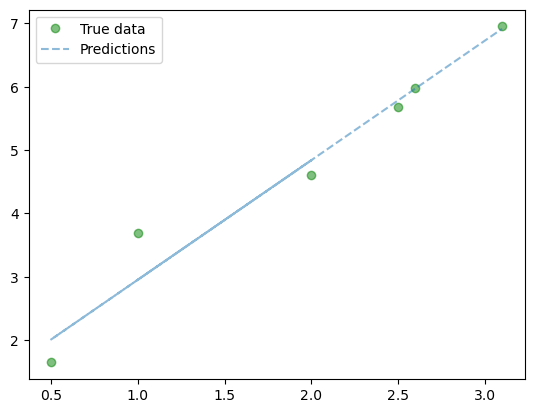

In [4]:
# Purely inference
predicted_y = model(torch.from_numpy(x).requires_grad_()).data.numpy()
print("标签Y:", y)
print("预测Y:", predicted_y)

# Clear figure
plt.clf()

# Get predictions
# predicted = model(torch.from_numpy(x).requires_grad_()).data.numpy()

# Plot true data
plt.plot(x, y, 'go', label='True data', alpha=0.5)

# Plot predictions
plt.plot(x, predicted_y, '--', label='Predictions', alpha=0.5)

# Legend and plot
plt.legend(loc='best')
plt.show()